# 股价 × 估值通道 × 买卖点

对**回测基准臂（V4 面板，§9.7.1.2）**跑出来的每一笔成交做可视化，用来回答一个问题：
**买入侧和卖出侧到底在发生什么。**

每只票三张图：

| 图 | 内容 |
| --- | --- |
| ① 价格 | 日蜡烛 + MA20/MA60 + **`P/V = 0.3/0.5/0.8/1.0/1.2/1.5/2.0` 七条通道**（即 `价 = 该倍数 × 内在价值 V`）+ 买卖点 + 每个周期的建仓日止损价 |
| ② `P/V` | 逐日 `P/V` 曲线，横线标出同样七个刻度，并**粗线标出 §9.7.1 的买入线与减持线**（现为 1.00 / 2.50） |
| ③ 持仓市值 | 由成交流水逐日重建，看钱什么时候真的在这只票上 |

**换股票只改下面 `CODE`（或直接调 `plot_case("600519")`）。**

---

**三条读图须知**

1. **通道是「倍数 × V」，V 每天都在变**，所以通道线本身是弯的，不是水平线。
2. **两条线自 v2.98 起是 1.00 与 2.50**（用户 2026-08-14 指定）。买入线与黑色中轴重合，
   减持线在 `P/V=2.5`——**图上会看到减持线几乎从不触发**，卖出实际由换仓与建仓日止损承担。
   v2.97 及以前是买 1.5884 / 减 1.1044，那时大多数买点落在中轴**上方**；翻旧图时注意这个差别。
3. **均线按回测的真实口径算在「不复权原始价」上**（`backtest_valuation_strategy.py` 的
   `moving_averages(prices)`，而 `prices` 是原始收盘）。故 **10 送 10 那天原始价腰斩，
   MA20 要二十个交易日才跟上**——图上会看到均线在除权日之后悬在价格上方。
   这不是绘图假象，**是策略当天真的看到的东西**，除权日已用竖虚线标出。


## 数据与重建

四份输入，都可重建：

| 用途 | 文件 | 是否入库 |
| --- | --- | --- |
| 日线（**不复权原始价**） | `data/raw/ohlcv/<代码>.csv` | 入库 |
| 除权除息 | `data/raw/corporate_actions/a_share_corporate_actions.csv` | 入库 |
| 逐日估值状态（`P/V`、内在价值） | `data/processed/a_share_daily_states_adopted.csv` | 92MB，`.gitignore` 内 |
| 成交流水与周期 | `data/processed/backtest/v4_baseline_trade_log.csv`、`..._V4LONG_trades.csv` | 否，按下面重建 |

成交流水与周期的重建命令（**就是 §9.7.1.2 的基准臂，只多加 `--trade-log`**）：

```bash
python3 scripts/backtest_valuation_strategy.py \
  --strategy trend --trend-tranche --x 1.0 --trend-ma 20 60 \
  --max-corr 0.85 --corr-window 252 --scan-depth 40 --max-positions 999 \
  --swap --swap-partial --sell-trend-ma 20 \
  --lot-size 100 --lot-ratio-cooldown --exec-delay 1 --exec-price close \
  --fee-preset user \
  --width 0.0 --sell-line 2.50 --swap-margin 0.15 \
  --daily-states data/processed/a_share_daily_states_adopted.csv \
  --universe-file data/processed/pit_attention/panel_moat_bank_v4.csv \
  --since 2009-11-01 --label-suffix _V4LONG \
  --trade-log data/processed/backtest/v4_baseline_trade_log.csv
```

逐日估值状态的重建见 §9.7.1.2 最后一段（先按 v2.90 口径建带，再对银行套股利折现）。


In [1]:
# ============================== 配置：只改这一格 ==============================
CODE   = "000651"            # 股票代码（六位，带前导零）
SINCE  = "2009-11-01"        # 画图起点（回测基准臂的长跑起点）
UNTIL  = None                # 画图终点，None = 到最后

PV_LINES = [0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0]   # 要画的 P/V 通道
BUY_LINE, SELL_LINE = 1.00, 2.50                 # §9.7.1 的两条线（v2.98 由 1.5884/1.1044 改）

ADJUST = True     # True = 前复权显示（价与估值带同乘一个因子，P/V 不变，曲线连续）
                  # False = 原始价显示（除权日价与带同时跳，P/V 同样不变）
MARK   = "first"  # "first" = 每个建仓→清仓周期只标第一笔买与第一笔卖；"all" = 每笔都标；"none"
CANDLE = "auto"   # "auto" = 超过 800 根自动改画收盘线；True/False = 强制
# ============================================================================

import csv, collections, bisect, math
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import rcParams
from matplotlib.collections import LineCollection

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OHLCV   = ROOT / "data/raw/ohlcv"
ACTIONS = ROOT / "data/raw/corporate_actions/a_share_corporate_actions.csv"
DAILY   = ROOT / "data/processed/a_share_daily_states_adopted.csv"
PANEL   = ROOT / "data/processed/pit_attention/panel_moat_bank_v4.csv"
LEDGER  = ROOT / "data/processed/backtest/v4_baseline_trade_log.csv"
# 周期文件名里嵌着参数，改线就会换名——按 `_V4LONG_` 后缀取最新一份，免得每次改线都要改路径。
_cyc = sorted((ROOT / "data/processed/backtest").glob("*_V4LONG_trades.csv"))
CYCLES  = _cyc[-1] if _cyc else ROOT / "data/processed/backtest/_V4LONG_trades.csv"

rcParams["font.sans-serif"] = ["Heiti SC", "Arial Unicode MS", "PingFang SC"]
rcParams["axes.unicode_minus"] = False
rcParams["figure.dpi"] = 110

for p in (OHLCV, ACTIONS, DAILY, PANEL, LEDGER, CYCLES):
    print(("  OK  " if p.exists() else "缺失! ") + str(p.relative_to(ROOT)))

  OK  data/raw/ohlcv
  OK  data/raw/corporate_actions/a_share_corporate_actions.csv
  OK  data/processed/a_share_daily_states_adopted.csv
  OK  data/processed/pit_attention/panel_moat_bank_v4.csv
  OK  data/processed/backtest/v4_baseline_trade_log.csv
  OK  data/processed/backtest/trend_x1_w0_x1c_sma20_swap_corr0.85_tranche_sl2.5_sp_lot100_lrc_V4LONG_trades.csv


In [2]:
# ------------------------------ 加载 ------------------------------
def load_ohlcv(code):
    """不复权原始日线。返回按日期升序的 (日期, 开, 高, 低, 收) 五条并列表。"""
    d, o, h, l, c = [], [], [], [], []
    with open(OHLCV / f"{code}.csv", encoding="utf-8") as fh:
        for r in csv.DictReader(fh):
            try:
                vals = float(r["open"]), float(r["high"]), float(r["low"]), float(r["close"])
            except (TypeError, ValueError):
                continue
            d.append(r["date"]); o.append(vals[0]); h.append(vals[1]); l.append(vals[2]); c.append(vals[3])
    return d, o, h, l, c


def load_actions(code):
    """{除权日: (每股现金红利, 送转比)}；同日多条相加/连乘，与回测口径一致。"""
    ev = {}
    with open(ACTIONS, encoding="utf-8") as fh:
        for r in csv.DictReader(fh):
            if r["security_code"] != code:
                continue
            day = (r.get("ex_dividend_date") or "").strip()
            if len(day) != 10:
                continue
            cash  = float(r.get("cash_per_share") or 0)
            ratio = float(r.get("share_ratio") or 0)
            c0, r0 = ev.get(day, (0.0, 0.0))
            ev[day] = (c0 + cash, (1 + r0) * (1 + ratio) - 1)
    return ev


_STATE_CACHE = {}

def load_states(code):
    """{日期: (内在价值, P/V)}。逐日状态 92MB，用行首前缀过滤、不进 DictReader，并缓存。"""
    if code in _STATE_CACHE:
        return _STATE_CACHE[code]
    out = {}
    prefix = code + ","
    with open(DAILY, encoding="utf-8") as fh:
        head = next(fh).rstrip("\n").split(",")
        i_d, i_v, i_r = head.index("date"), head.index("intrinsic_value"), head.index("valuation_ratio")
        for line in fh:
            if not line.startswith(prefix):
                continue
            f = line.rstrip("\n").split(",")
            try:
                out[f[i_d]] = (float(f[i_v]), float(f[i_r]))
            except (ValueError, IndexError):
                pass
    _STATE_CACHE[code] = out
    return out


def load_panel(code):
    """[(在册起, 在册止)]，V4 面板已含退出与重入，故可能是多段。"""
    out = []
    with open(PANEL, encoding="utf-8-sig") as fh:
        for r in csv.DictReader(fh):
            if r["security_code"] == code:
                # `effective_to` 为空 = 至今仍在册（V4 面板对未退出的公司留空）
                out.append((r["effective_from"], r["effective_to"] or "9999-12-31"))
    out.sort()
    merged = []                      # 相邻档首尾相接的合成一段，只留真实断点
    for a, b in out:
        if merged and merged[-1][1] == a:
            merged[-1][1] = b
        else:
            merged.append([a, b])
    return [tuple(x) for x in merged]


def load_fills(code):
    """逐笔成交流水（含每笔的 P/V 与原因）。"""
    with open(LEDGER, encoding="utf-8") as fh:
        return [r for r in csv.DictReader(fh) if r["security_code"] == code]


def load_cycles(code):
    """建仓→清仓周期（含建仓日止损价与清仓原因）。"""
    with open(CYCLES, encoding="utf-8") as fh:
        return [r for r in csv.DictReader(fh) if r["security_code"] == code]


NAMES = {}
with open(ROOT / "data/raw/a_share_securities.csv", encoding="utf-8-sig") as fh:
    for r in csv.DictReader(fh):
        NAMES[r["security_code"]] = r.get("security_name", "")
print(f"证券名 {len(NAMES):,} 条已载入")

证券名 5,653 条已载入


In [3]:
# ------------------------------ 计算 ------------------------------
def fwd_factors(dates, closes, ev):
    """前复权因子 A[i]：把第 i 天的价折到「最新一期」的口径。

    除权日 e 的因子 k = ((前收 − 每股红利) / (1 + 送转比)) / 前收，**e 之前的全部价格乘 k**。
    价与估值带同乘 A，故 `P/V` 一位不变——复权只改 y 轴刻度，不改任何判定。
    """
    idx = {d: i for i, d in enumerate(dates)}
    ks = {}
    for day, (cash, ratio) in ev.items():
        i = idx.get(day)
        if i is None or i == 0:
            continue
        prev = closes[i - 1]
        if prev > 0:
            ks[i] = ((prev - cash) / (1 + ratio)) / prev
    A, acc = [1.0] * len(dates), 1.0
    for i in range(len(dates) - 1, -1, -1):
        A[i] = acc
        if i in ks:
            acc *= ks[i]
    return A


def sma(values, window):
    """与 `backtest_valuation_strategy.py:moving_averages` 同一算法，**算在原始价上**。"""
    out, total = [None] * len(values), 0.0
    for i, v in enumerate(values):
        total += v
        if i >= window:
            total -= values[i - window]
        if i >= window - 1:
            out[i] = total / window
    return out


def position_value(dates, closes, fills, ev):
    """由流水逐日重建持仓市值（原始价口径）。除权日先调股数，再记当日成交。"""
    by_day = collections.defaultdict(list)
    for r in fills:
        by_day[r["date"]].append(r)
    shares, out = 0.0, []
    for i, day in enumerate(dates):
        if day in ev:
            shares *= (1 + ev[day][1])
        for r in by_day.get(day, []):
            s = float(r["shares"])
            shares += s if r["action"] == "买入" else -s
        shares = max(shares, 0.0)
        out.append(shares * closes[i])
    return out


def mark_points(fills, cycles, mode):
    """要标注的成交点。first = 每个周期的第一笔买 + 第一笔卖。"""
    if mode == "none":
        return [], []
    buys  = [r for r in fills if r["action"] == "买入"]
    sells = [r for r in fills if r["action"] == "卖出"]
    if mode == "all":
        return buys, sells
    keep_b, keep_s = [], []
    for cyc in cycles:
        a, b = cyc["entry_date"], cyc["exit_date"] or "9999"
        inb = [r for r in buys  if a <= r["date"] <= b]
        ins = [r for r in sells if a <= r["date"] <= b]
        if inb:
            keep_b.append(inb[0])
        if ins:
            keep_s.append(ins[0])
    return keep_b, keep_s


D = lambda s: mdates.date2num(datetime.strptime(s, "%Y-%m-%d"))

In [4]:
# ------------------------------ 绘图 ------------------------------
def _candles(ax, x, o, h, l, c, width):
    up = [i for i in range(len(x)) if c[i] >= o[i]]
    dn = [i for i in range(len(x)) if c[i] <  o[i]]
    for idx, col in ((up, "#d62728"), (dn, "#2ca02c")):        # A 股惯例：涨红跌绿
        if not idx:
            continue
        ax.add_collection(LineCollection([[(x[i], l[i]), (x[i], h[i])] for i in idx],
                                         colors=col, linewidths=0.5, zorder=2))
        ax.bar([x[i] for i in idx], [max(abs(c[i] - o[i]), 1e-9) for i in idx],
               bottom=[min(o[i], c[i]) for i in idx], width=width,
               color=col, edgecolor=col, linewidth=0.2, zorder=3)


def _band_color(m):
    if m == 1.0:
        return "black", 1.6, 1.0
    if m < 1.0:
        return plt.cm.Greens(0.35 + 0.5 * (1 - m)), 1.0, 0.9
    return plt.cm.Reds(0.25 + 0.35 * min(m - 1, 1.2)), 1.0, 0.9


def plot_case(code, since=None, until=None, pv_lines=None, adjust=None,
              mark=None, candle=None, figsize=(15, 10)):
    since  = since  or SINCE
    until  = until  or UNTIL
    pv     = pv_lines if pv_lines is not None else PV_LINES
    adjust = ADJUST if adjust is None else adjust
    mark   = MARK   if mark   is None else mark
    candle = CANDLE if candle is None else candle

    dates, o, h, l, c = load_ohlcv(code)
    ev      = load_actions(code)
    states  = load_states(code)
    spans   = load_panel(code)
    fills   = load_fills(code)
    cycles  = load_cycles(code)
    A       = fwd_factors(dates, c, ev) if adjust else [1.0] * len(dates)
    ma20, ma60 = sma(c, 20), sma(c, 60)
    posval  = position_value(dates, c, fills, ev)

    lo = bisect.bisect_left(dates, since)
    hi = bisect.bisect_right(dates, until) if until else len(dates)
    rng = range(lo, hi)
    if not len(rng):
        print(f"{code} 在 {since}~{until} 无行情"); return

    x  = [D(dates[i]) for i in rng]
    fa = lambda seq: [None if seq[i] is None else seq[i] * A[i] for i in rng]
    name = NAMES.get(code, "")
    n_bars = len(x)
    use_candle = (n_bars <= 800) if candle == "auto" else bool(candle)
    width = max((x[-1] - x[0]) / max(n_bars, 1) * 0.7, 0.35)

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True,
                             gridspec_kw={"height_ratios": [3.2, 1.15, 0.85], "hspace": 0.06})
    ax, ax2, ax3 = axes

    # ---- 在册期底色（V4 面板：含退出与重入，故可能有断档）----
    for a, b in spans:
        ax.axvspan(D(max(a, dates[lo])), D(min(b, dates[hi - 1])),
                   color="#4c72b0", alpha=0.05, zorder=0)

    # ---- 估值通道：y = 倍数 × V ----
    days_with_v = [i for i in rng if dates[i] in states and states[dates[i]][0] > 0]
    if days_with_v:
        vx = [D(dates[i]) for i in days_with_v]
        for m in sorted(pv):
            col, lw, al = _band_color(m)
            ax.plot(vx, [states[dates[i]][0] * m * A[i] for i in days_with_v],
                    color=col, lw=lw, alpha=al, zorder=1,
                    label=f"P/V={m:g}" + ("（估值中轴）" if m == 1.0 else ""))
        ax.plot(vx, [states[dates[i]][0] * BUY_LINE * A[i] for i in days_with_v],
                color="#1f77b4", lw=1.8, ls="--", zorder=4, label=f"买入线 {BUY_LINE}")
        ax.plot(vx, [states[dates[i]][0] * SELL_LINE * A[i] for i in days_with_v],
                color="#9467bd", lw=1.8, ls="--", zorder=4, label=f"减持线 {SELL_LINE}")

    # ---- 蜡烛 / 收盘线 + 均线 ----
    if use_candle:
        _candles(ax, x, fa(o), fa(h), fa(l), fa(c), width)
    else:
        ax.plot(x, fa(c), color="#333333", lw=0.9, zorder=3, label="收盘")
    ax.plot(x, fa(ma20), color="#ff7f0e", lw=0.9, alpha=0.95, zorder=4, label="MA20")
    ax.plot(x, fa(ma60), color="#8c564b", lw=0.9, alpha=0.95, zorder=4, label="MA60")

    # ---- 除权日（送转 ≥10送1 才画，纯派现不影响均线）----
    for day, (cash, ratio) in sorted(ev.items()):
        if ratio >= 0.1 and since <= day <= dates[hi - 1]:
            ax.axvline(D(day), color="#888888", ls=":", lw=0.8, zorder=1)

    # ---- 每个周期的建仓日止损价 ----
    for cyc in cycles:
        try:
            stop = float(cyc["entry_stop"])
        except (TypeError, ValueError):
            continue
        a = max(cyc["entry_date"], dates[lo]); b = min(cyc["exit_date"] or dates[hi - 1], dates[hi - 1])
        if stop <= 0 or a > b:
            continue
        i = bisect.bisect_left(dates, a)
        f = A[min(i, len(A) - 1)]
        ax.plot([D(a), D(b)], [stop * f, stop * f], color="#7f7f7f", lw=1.4, alpha=0.85, zorder=5)

    # ---- 买卖点 ----
    buys, sells = mark_points(fills, cycles, mark)
    pos = {d: i for i, d in enumerate(dates)}
    def scat(rows, marker, col, lbl):
        px = [D(r["date"]) for r in rows if since <= r["date"] <= dates[hi - 1] and r["date"] in pos]
        py = [float(r["price"]) * A[pos[r["date"]]] for r in rows
              if since <= r["date"] <= dates[hi - 1] and r["date"] in pos]
        if px:
            ax.scatter(px, py, marker=marker, s=64, c=col, edgecolors="white",
                       linewidths=0.7, zorder=8, label=f"{lbl}（{len(px)}）")
        return px
    bx = scat(buys,  "^", "#0d47a1", "买入")
    sx = scat(sells, "v", "#000000", "卖出")

    # 盈亏最大的三个周期，把清仓原因标在清仓点上
    ranked = sorted((r for r in cycles if r["exit_date"] and since <= r["exit_date"] <= dates[hi - 1]),
                    key=lambda r: -abs(float(r["proceeds"]) - float(r["invested"])))[:3]
    for r in ranked:
        i = pos.get(r["exit_date"])
        if i is None:
            continue
        money = (float(r["proceeds"]) - float(r["invested"])) / 1e4
        ax.annotate(f"{r['exit_date']} {money:+,.0f}万\n{r['exit_reason']}",
                    (D(r["exit_date"]), c[i] * A[i]), fontsize=7.5,
                    xytext=(6, 16), textcoords="offset points",
                    bbox=dict(boxstyle="round,pad=0.28", fc="#fffbe6", ec="#c9a227", lw=0.6, alpha=0.95),
                    arrowprops=dict(arrowstyle="->", lw=0.7, color="#c9a227"), zorder=9)

    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.set_ylabel("价格（" + ("前复权" if adjust else "原始价") + "，对数轴）")
    closed = [r for r in cycles if r["exit_date"]]
    pnl = sum(float(r["proceeds"]) - float(r["invested"]) for r in closed)
    ax.set_title(f"{code} {name}｜在册 {len(spans)} 段｜买 {sum(1 for r in fills if r['action']=='买入')} 笔／"
                 f"卖 {sum(1 for r in fills if r['action']=='卖出')} 笔｜"
                 f"已平仓 {len(closed)} 个周期、合计 {pnl/1e4:+,.0f} 万", fontsize=12)
    ax.legend(ncol=6, fontsize=7.5, loc="upper left", framealpha=0.9)
    ax.grid(alpha=0.15)

    # ---- 第二张：P/V ----
    if days_with_v:
        ax2.plot([D(dates[i]) for i in days_with_v],
                 [states[dates[i]][1] for i in days_with_v], color="#333333", lw=0.9, zorder=3)
    for m in sorted(pv):
        col, lw, al = _band_color(m)
        ax2.axhline(m, color=col, lw=lw, alpha=al, zorder=1)
        ax2.annotate(f"{m:g}", (1.002, m), xycoords=("axes fraction", "data"),
                     fontsize=7, color=col if m != 1.0 else "black", va="center")
    ax2.axhline(BUY_LINE,  color="#1f77b4", lw=1.8, ls="--", zorder=4)
    ax2.axhline(SELL_LINE, color="#9467bd", lw=1.8, ls="--", zorder=4)
    # 量程按「实际 P/V ∪ 要画的刻度」定死。**不能用 axhspan(0, …)**——对数轴上的 0
    # 会把下界拉到 1e-12，整条曲线压成一条直线（首版踩中，宁德时代那张图就是）。
    seen = [states[dates[i]][1] for i in days_with_v] or [1.0]
    ylo = min(min(seen), min(pv)) / 1.35
    yhi = max(max(seen), max(pv)) * 1.35
    ax2.set_ylim(ylo, yhi)
    ax2.axhspan(ylo, BUY_LINE, color="#1f77b4", alpha=0.05, zorder=0)
    ticks = sorted({*pv, BUY_LINE, SELL_LINE})
    ax2.set_yticks([v for v in ticks if ylo <= v <= yhi])
    ax2.minorticks_off()
    for rows, marker, col in ((buys, "^", "#0d47a1"), (sells, "v", "#000000")):
        px = [D(r["date"]) for r in rows if since <= r["date"] <= dates[hi - 1]]
        py = [float(r["pv_ratio"]) if r["pv_ratio"] else
              states.get(r["date"], (0, float("nan")))[1]
              for r in rows if since <= r["date"] <= dates[hi - 1]]
        if px:
            ax2.scatter(px, py, marker=marker, s=42, c=col, edgecolors="white",
                        linewidths=0.6, zorder=8)
    ax2.set_yscale("log")
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
    ax2.set_ylabel("P/V")
    ax2.grid(alpha=0.15)

    # ---- 第三张：持仓市值 ----
    ax3.fill_between(x, 0, [posval[i] / 1e4 for i in rng], color="#4c72b0", alpha=0.5, lw=0)
    ax3.set_ylabel("持仓市值（万）")
    ax3.grid(alpha=0.15)
    ax3.xaxis.set_major_locator(mdates.YearLocator(2))
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax3.get_xticklabels(), rotation=0)
    plt.show()
    return fig

## 一、在上面赚到钱的：格力电器、陕西煤业

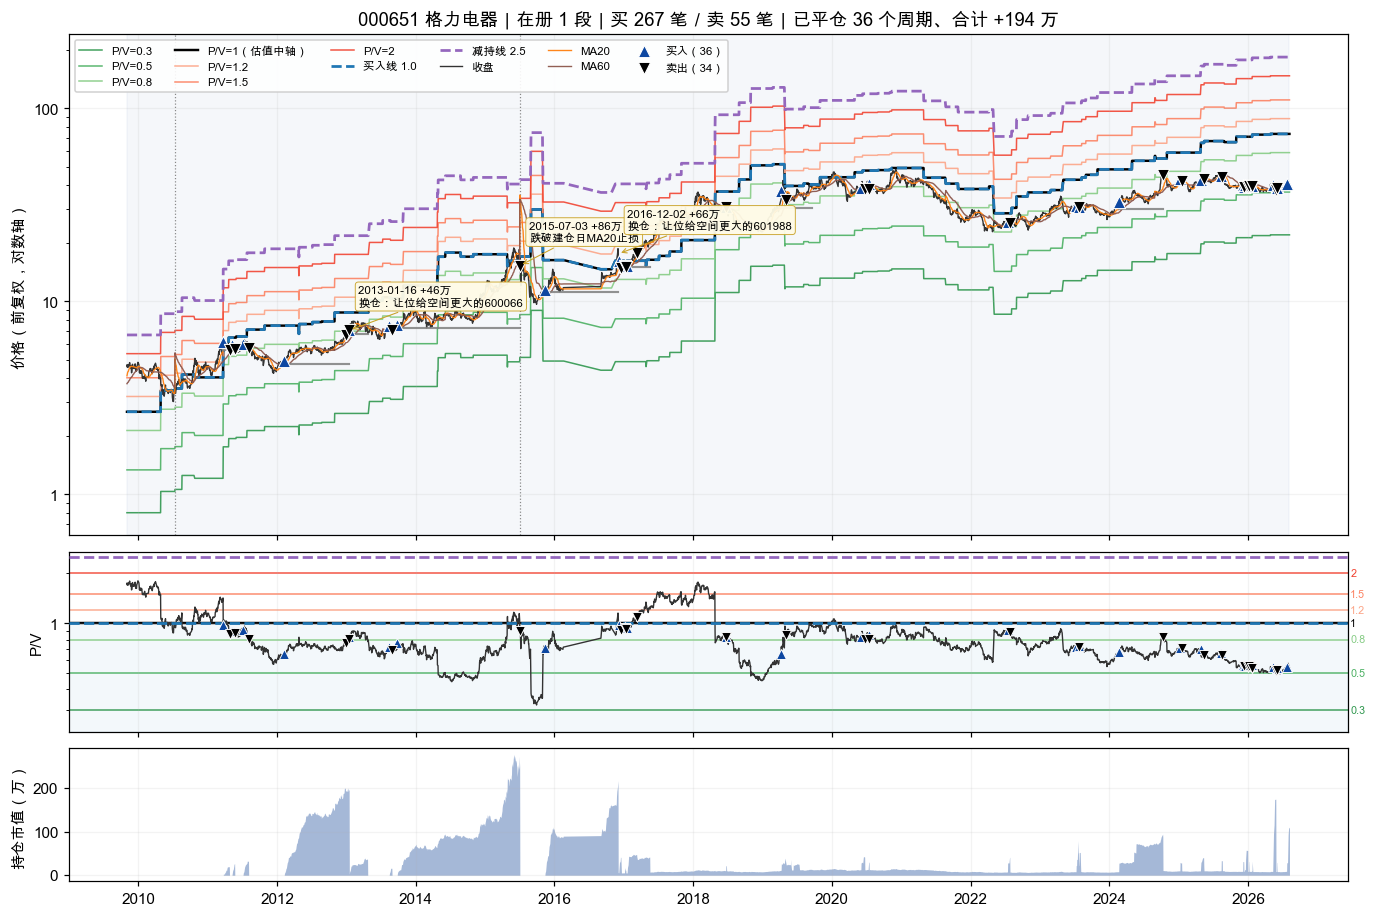

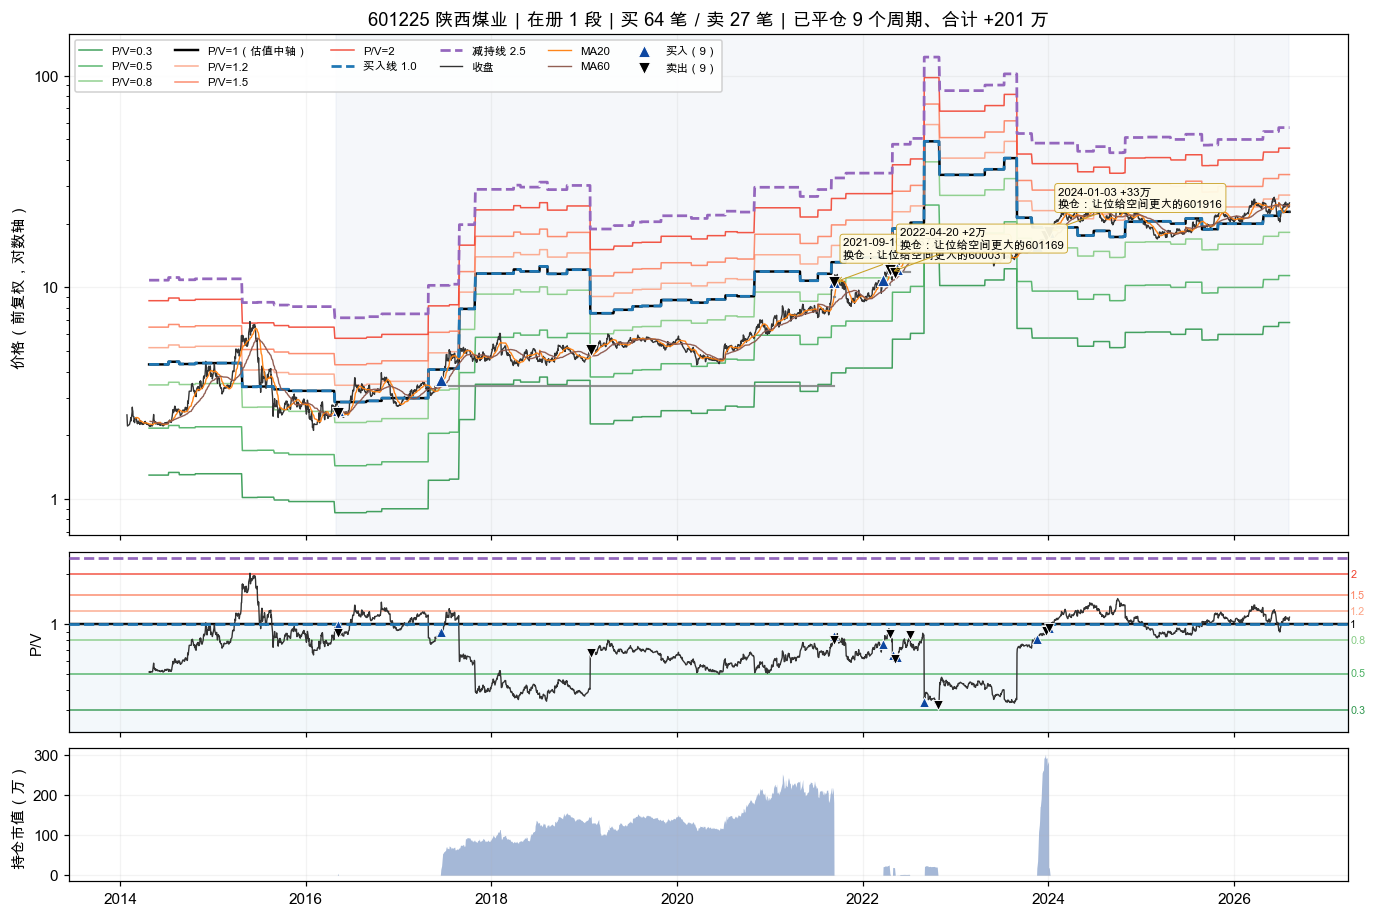

In [5]:
plot_case("000651")    # 格力电器
plot_case("601225");   # 陕西煤业（末尾分号：不重复显示返回的 fig）

## 二、一直关心却没赚到钱的五只

**贵州茅台在册二十三年、成交三十六笔，最后净赚 −1 万**；
**宁德时代与迈瑞医疗一笔都没成交**（下面两格会打印原因，不出图）。

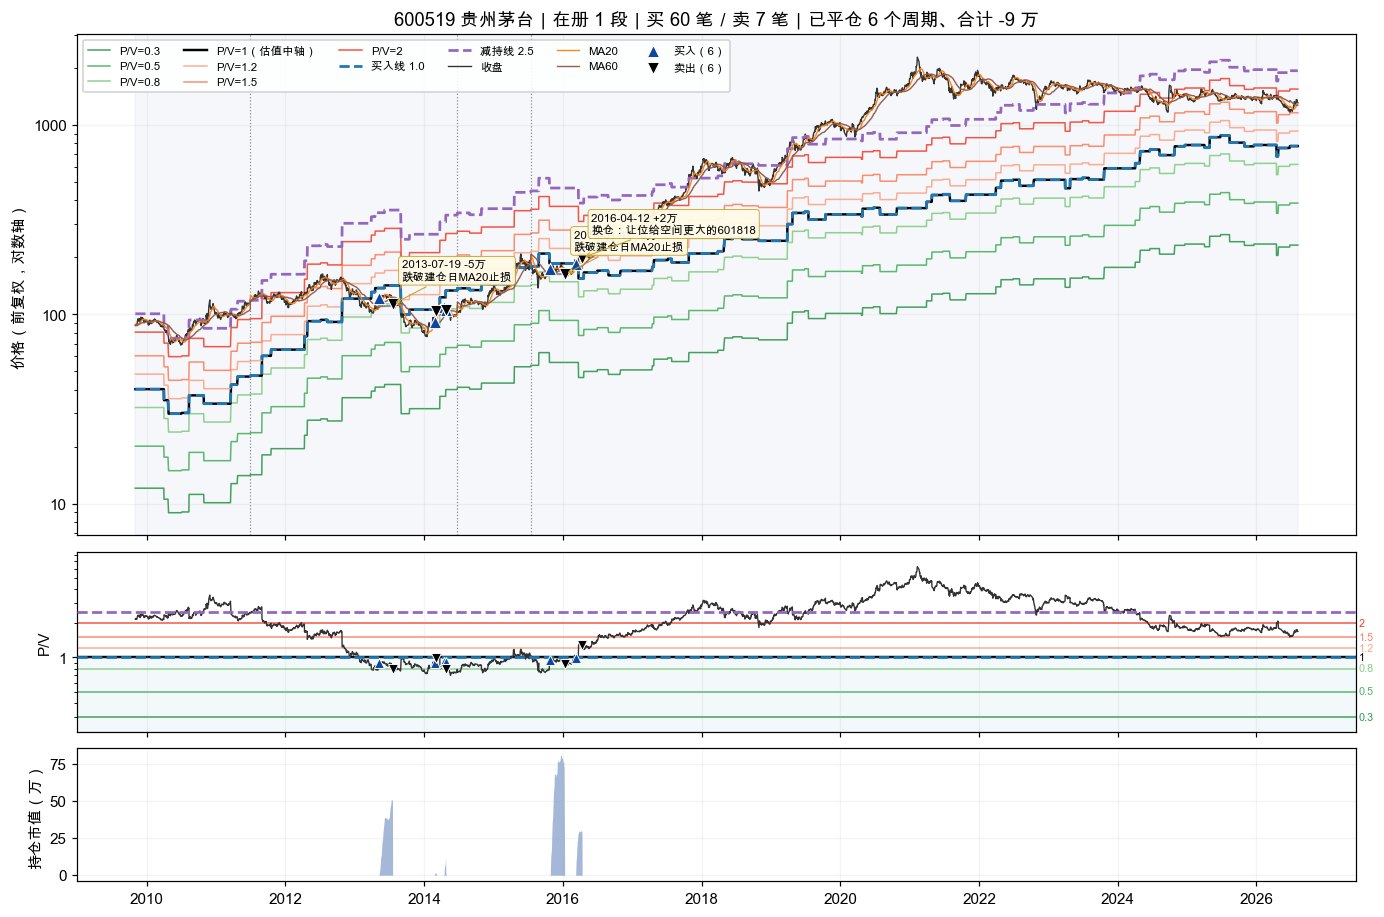

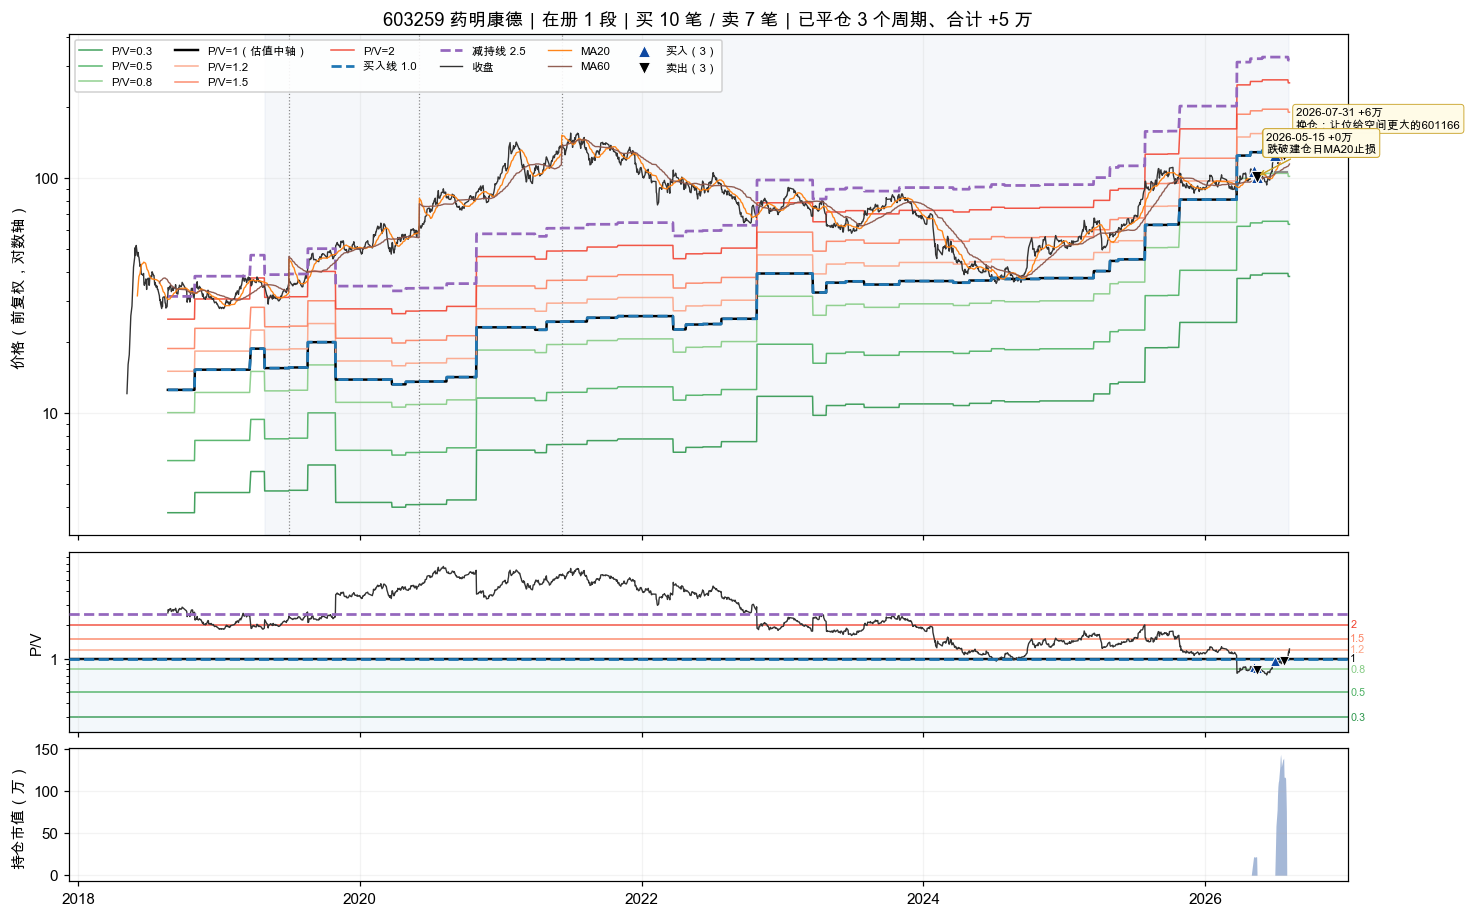

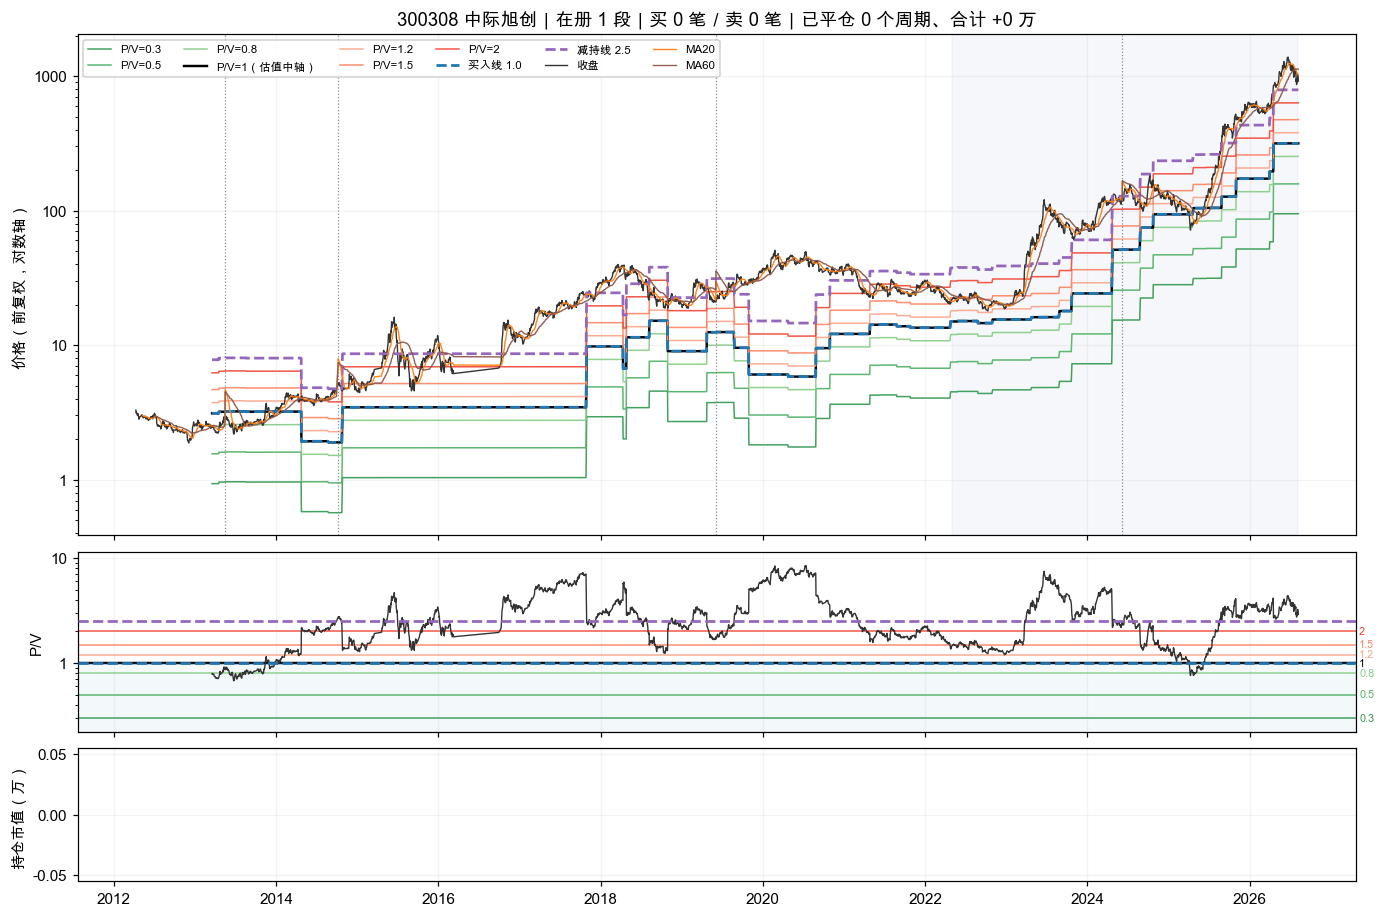

In [6]:
for c in ["600519", "603259", "300308"]:      # 茅台、药明康德、中际旭创
    plot_case(c)

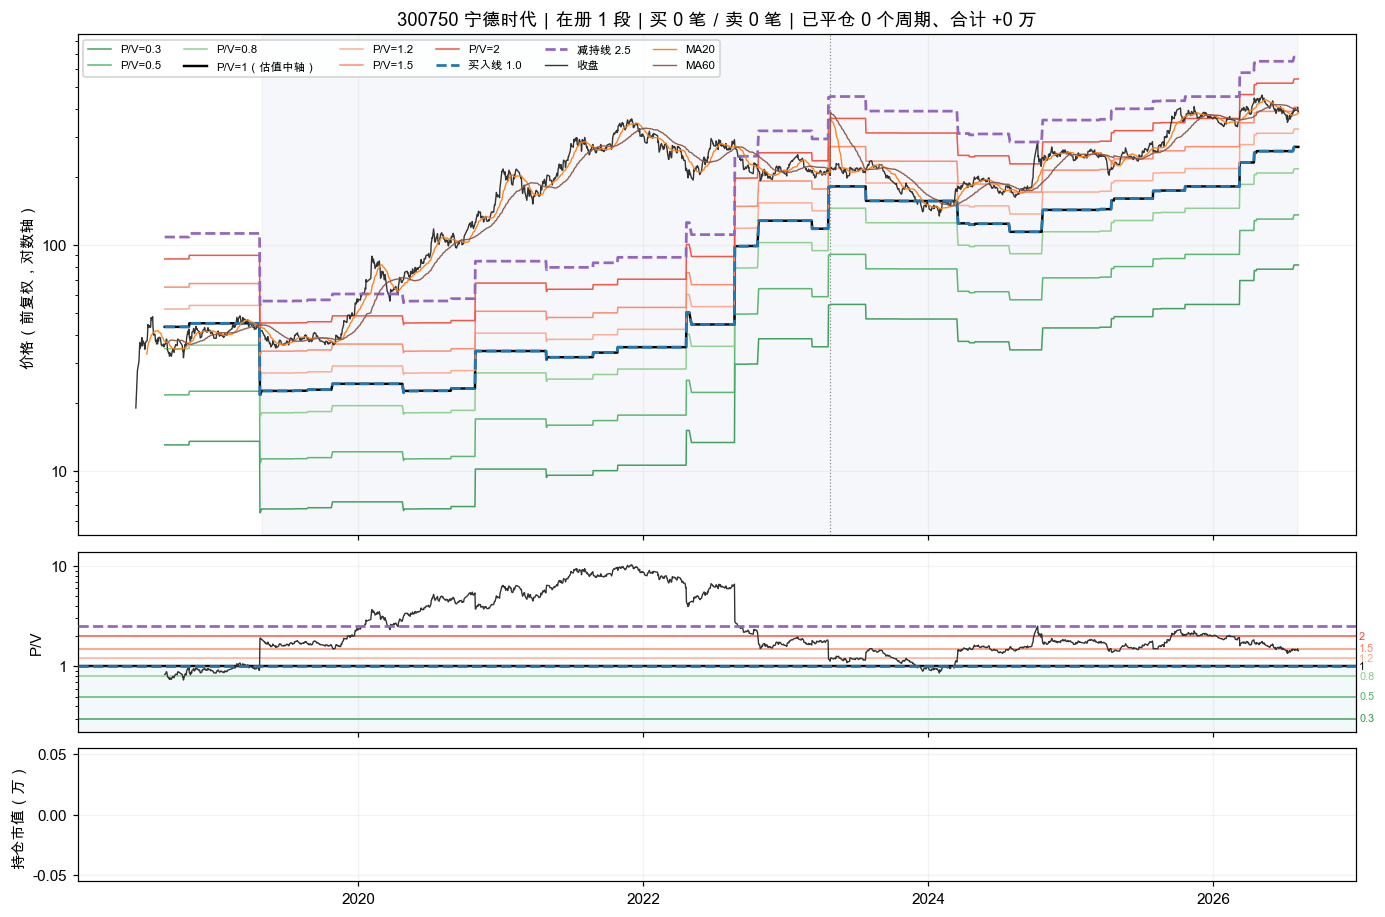

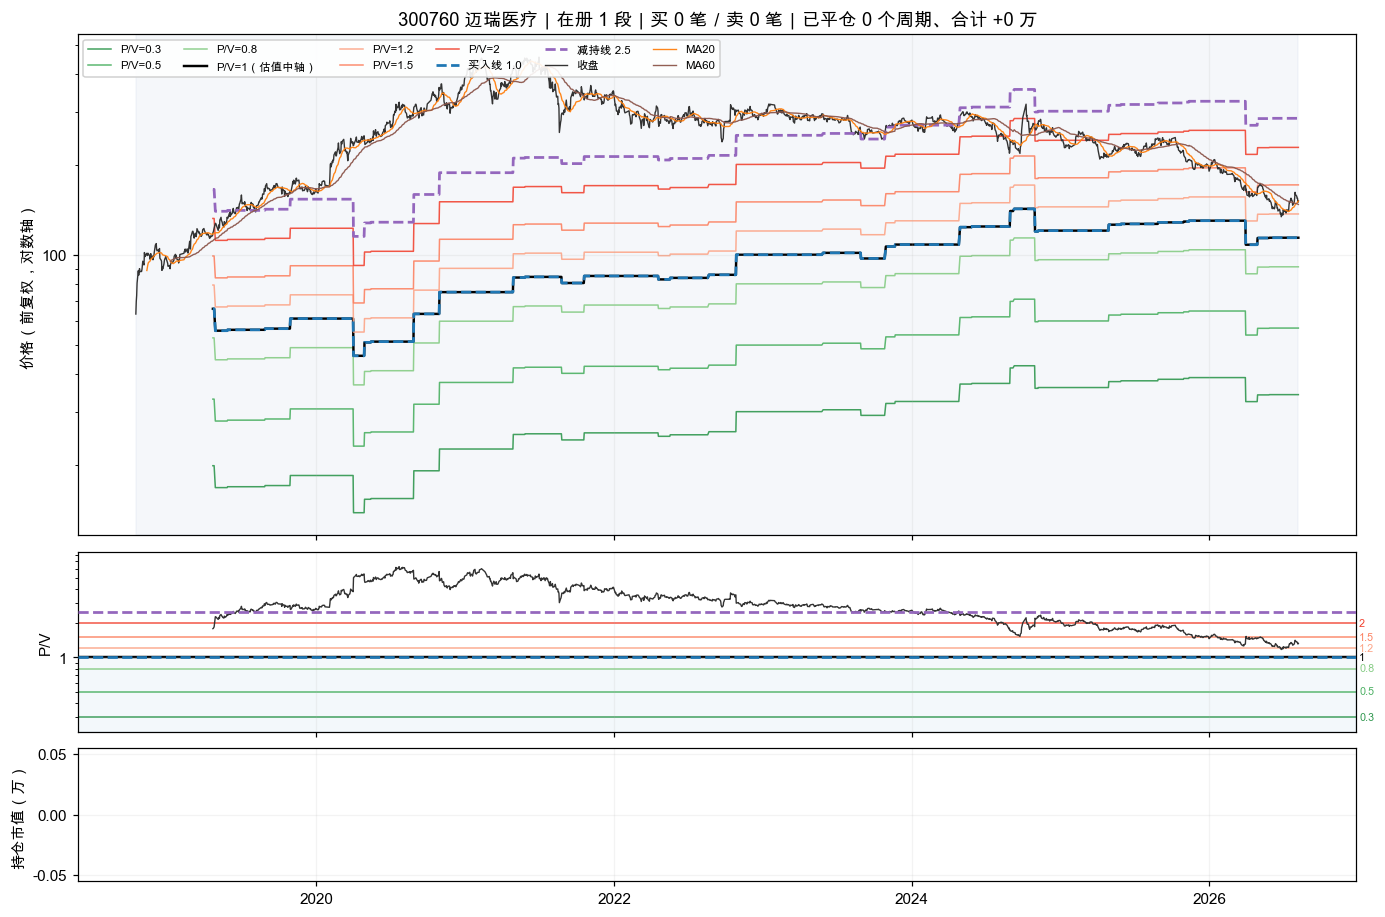

In [7]:
# 宁德时代、迈瑞医疗：全程零成交，先看闸门到底哪一道没开
for c in ["300750", "300760"]:
    plot_case(c, mark="none")

## 三、闸门拆解表

对每只票逐日重放两道闸：**① `P/V ≤ 买入线`；② `收盘 > MA20 > MA60`**，
统计各自开了多少天、同时开了多少天，再和实际成交笔数对照。
**「两闸同开却没买」= 输在排序或资金，不是输在闸门。**

In [8]:
def gate_table(codes, since=None):
    since = since or SINCE
    print(f"{'代码':<8}{'名称':<9}{'在册日':>7}{'过买入线':>9}{'过走势':>7}{'两闸同开':>9}"
          f"{'占在册':>8}{'买笔':>6}{'建仓次':>7}{'买入P/V中位':>12}")
    for code in codes:
        dates, o, h, l, c = load_ohlcv(code)
        states, spans = load_states(code), load_panel(code)
        ma20, ma60 = sma(c, 20), sma(c, 60)
        fills = load_fills(code)
        inpanel = lambda d: any(a <= d < b for a, b in spans)   # spans 已把空的 effective_to 补成 9999
        n = n_pv = n_tr = n_both = 0
        for i, d in enumerate(dates):
            if d < since or not inpanel(d) or d not in states:
                continue
            n += 1
            cheap = states[d][1] <= BUY_LINE
            trend = ma20[i] is not None and ma60[i] is not None and c[i] > ma20[i] > ma60[i]
            n_pv += cheap; n_tr += trend; n_both += (cheap and trend)
        buys = [r for r in fills if r["action"] == "买入"]
        pvs = sorted(float(r["pv_ratio"]) for r in buys if r["pv_ratio"])
        med = f"{pvs[len(pvs)//2]:.3f}" if pvs else "—"
        firsts = sum(1 for r in buys if r["reason"] == "首次建仓")
        print(f"{code:<8}{NAMES.get(code,''):<9}{n:>7}{n_pv:>9}{n_tr:>7}{n_both:>9}"
              f"{(n_both/n*100 if n else 0):>7.0f}%{len(buys):>6}{firsts:>7}{med:>12}")

gate_table(["000651", "601225", "601001", "600585",
            "600519", "603259", "300308", "300750", "300760"])

代码      名称           在册日     过买入线    过走势     两闸同开     占在册    买笔    建仓次     买入P/V中位
000651  格力电器        3906     3278   1283      953     24%   267     36       0.746
601225  陕西煤业        2495     1826    819      572     23%    64      9       0.758


601001  晋控煤业        2605     1870    621      491     19%   110     13       0.479


600585  海螺水泥        3969     3451   1084      868     22%   201     12       0.610
600519  贵州茅台        4068      681   1467      180      4%    60      6       0.913
603259  药明康德        1765      110    512       35      2%    10      3       0.939
300308  中际旭创        1036       42    414        5      0%     0      0           —


300750  宁德时代        1765       59    628        3      0%     0      0           —
300760  迈瑞医疗        1770        0    478        0      0%     0      0           —


## 四、`P/V` 到底能不能预测未来

把 V4 面板在册期内的**每月一个观测**取出来，按 `P/V` 分十档，看各档**其后 250 个交易日的总回报**
（含现金分红与送转，故可跨除权日比较）。这检验的是估值带在排序上的信息量本身，与交易规则无关。

**看完这张表再回去看两条线落在第几档。**

In [9]:
import bisect, statistics as st, math

_PX, _EV = {}, {}

def _series(code):
    if code not in _PX:
        d, c = [], []
        try:
            with open(OHLCV / f"{code}.csv", encoding="utf-8") as fh:
                next(fh)
                for ln in fh:
                    f = ln.split(","); d.append(f[0]); c.append(float(f[2]))
        except (OSError, ValueError):
            pass
        _PX[code] = (d, c)
    return _PX[code]


def fwd_return(code, day, n=250):
    """从 day 起持有 n 个交易日的**总回报**：含现金分红与送转，故可跨除权日比较。"""
    d, c = _series(code)
    if not d:
        return None
    i = bisect.bisect_left(d, day)
    if i >= len(d) or i + n >= len(d) or c[i] <= 0:
        return None
    if code not in _EV:
        _EV[code] = load_actions(code)
    shares, cash = 1.0, 0.0
    for j in range(i + 1, i + n + 1):
        e = _EV[code].get(d[j])
        if e:
            cash += shares * e[0]; shares *= (1 + e[1])
    return (shares * c[i + n] + cash) / c[i] - 1


def _spearman(a, b):
    rank = lambda v: {i: r for r, i in enumerate(sorted(range(len(v)), key=lambda i: v[i]))}
    ra, rb = rank(a), rank(b)
    x = [ra[i] for i in range(len(a))]; y = [rb[i] for i in range(len(b))]
    mx, my = st.mean(x), st.mean(y)
    return (sum((xi - mx) * (yi - my) for xi, yi in zip(x, y)) /
            math.sqrt(sum((xi - mx) ** 2 for xi in x) * sum((yi - my) ** 2 for yi in y)))


def pv_decile_table(day_of_month="15", horizon=250):
    spans = {}
    with open(PANEL, encoding="utf-8-sig") as fh:
        for r in csv.DictReader(fh):
            spans.setdefault(r["security_code"], []).append(
                (r["effective_from"], r["effective_to"] or "9999-12-31"))
    obs = []
    with open(DAILY, encoding="utf-8") as fh:
        head = next(fh).rstrip("\n").split(",")
        i_c, i_d, i_r = head.index("security_code"), head.index("date"), head.index("valuation_ratio")
        for line in fh:
            f = line.rstrip("\n").split(",")
            if f[i_d][8:10] != day_of_month:
                continue
            if not any(a <= f[i_d] < b for a, b in spans.get(f[i_c], ())):
                continue
            try:
                obs.append((f[i_c], f[i_d], float(f[i_r])))
            except ValueError:
                pass
    res = []
    for c, d, ratio in obs:
        r = fwd_return(c, d, horizon)
        if r is not None:
            res.append((ratio, r))
    res.sort()
    n, k = len(res), 10
    print(f"面板内月度观测 {len(obs):,}，可算前瞻 {horizon} 日回报的 {n:,}\n")
    print(f"{'十分位':>6}{'P/V 区间':>18}{'前瞻中位':>11}{'均值':>9}{'为正':>8}")
    for i in range(k):
        seg = res[i * n // k:(i + 1) * n // k]
        rs = [r for _, r in seg]
        tag = ""
        if seg[0][0] <= SELL_LINE <= seg[-1][0]:
            tag += "  ← 减持线"
        if seg[0][0] <= BUY_LINE <= seg[-1][0]:
            tag += "  ← 买入线"
        print(f"{i+1:>6}{f'{seg[0][0]:.2f}~{seg[-1][0]:.2f}':>18}"
              f"{st.median(rs)*100:>10.1f}%{st.mean(rs)*100:>8.1f}%"
              f"{sum(1 for x in rs if x > 0)/len(rs)*100:>7.0f}%{tag}")
    print(f"\nSpearman 秩相关 = {_spearman([x[0] for x in res], [x[1] for x in res]):+.4f}"
          f"（负 = 越便宜其后涨得越好）")

pv_decile_table()

面板内月度观测 16,666，可算前瞻 250 日回报的 15,112

   十分位            P/V 区间       前瞻中位       均值      为正
     1         0.13~0.77      15.8%    24.2%     71%
     2         0.77~0.99      11.0%    19.0%     68%
     3         0.99~1.20       3.0%    13.8%     55%  ← 买入线
     4         1.20~1.44       2.2%    13.5%     54%
     5         1.44~1.72       2.2%    13.0%     53%
     6         1.72~2.03       3.1%    15.5%     55%
     7         2.03~2.45       4.6%    15.2%     56%
     8         2.45~3.07       0.9%    13.8%     51%  ← 减持线
     9         3.07~4.23      -1.9%    16.5%     48%
    10        4.23~55.51      -7.6%     8.6%     43%

Spearman 秩相关 = -0.1325（负 = 越便宜其后涨得越好）


上表给出信号本身的形状，下表给出**钱实际进在哪一档**——两张一起看才知道买入线有没有在干活。

In [10]:
def entry_pv_table(edges=(0.77, 0.99, 1.20, 1.44, 1.72, 2.03, 2.45, 3.07, 4.23)):
    """每一笔买入按建仓当日 `P/V` 落进上表的十分位，看资金分布。"""
    with open(LEDGER, encoding="utf-8") as fh:
        rows = [r for r in csv.DictReader(fh) if r["action"] == "买入" and r["pv_ratio"]]
    amt = [(float(r["pv_ratio"]), float(r["amount"])) for r in rows]
    tot = sum(a for _, a in amt)
    lab = [f"≤{edges[0]:.2f}"] + [f"{edges[i]:.2f}~{edges[i+1]:.2f}" for i in range(len(edges) - 1)] \
          + [f">{edges[-1]:.2f}"]
    buck = {}
    for ratio, a in amt:
        i = bisect.bisect_right(edges, ratio)
        n0, a0 = buck.get(i, (0, 0.0))
        buck[i] = (n0 + 1, a0 + a)
    print(f"买入 {len(amt):,} 笔、合计 {tot/1e4:,.0f} 万\n")
    print(f"{'建仓当日 P/V':<18}{'档':>4}{'笔数':>7}{'金额(万)':>11}{'占资金':>9}")
    for i in range(len(edges) + 1):
        n, a = buck.get(i, (0, 0.0))
        print(f"{lab[i]:<18}{f'D{i+1}':>4}{n:>7}{a/1e4:>11,.0f}{a/tot*100:>8.1f}%")
    pvs = sorted(p for p, _ in amt)
    cheap = sum(a for p, a in amt if p <= edges[1]) / tot
    print(f"\n买入 P/V：中位 {pvs[len(pvs)//2]:.3f}｜P75 {pvs[3*len(pvs)//4]:.3f}｜"
          f"P90 {pvs[9*len(pvs)//10]:.3f}｜最大 {pvs[-1]:.3f}（买入线 {BUY_LINE}）")
    print(f"落在 D1+D2 的资金占 {cheap*100:.1f}%")

entry_pv_table()

买入 4,092 笔、合计 29,080 万

建仓当日 P/V             档     笔数      金额(万)      占资金
≤0.77               D1   2331     19,715    67.8%
0.77~0.99           D2   1663      8,963    30.8%
0.99~1.20           D3     98        402     1.4%
1.20~1.44           D4      0          0     0.0%
1.44~1.72           D5      0          0     0.0%
1.72~2.03           D6      0          0     0.0%
2.03~2.45           D7      0          0     0.0%
2.45~3.07           D8      0          0     0.0%
3.07~4.23           D9      0          0     0.0%
>4.23              D10      0          0     0.0%

买入 P/V：中位 0.729｜P75 0.882｜P90 0.957｜最大 1.000（买入线 1.0）
落在 D1+D2 的资金占 98.6%


## 五、换仓之后的一年：卖掉的 vs 买进的

`换仓` 是**盈利周期最主要的终结方式**。这一格做配对检验：在每次换仓的清仓日，
比较**被卖掉的那只**与**换进来的那只**其后 N 个交易日的总回报。
如果「候选比在手便宜 0.15 以上就换」这条规则带信息，配对差应当稳定为正。

注：`--swap-partial` 下换仓是每天减一档，清仓日是**最后一档卖出的那天**，
故本检验测的是「换完的那一刻起，换进来的是否更好」。

In [11]:
import re

def swap_forward_test(horizons=(20, 60, 125, 250, 500, 750)):
    with open(CYCLES, encoding="utf-8") as fh:
        rows = [r for r in csv.DictReader(fh) if r["exit_date"]]
    pairs = []
    for r in rows:
        m = re.search(r"换仓：让位给空间更大的(\d{6})", r["exit_reason"])
        if m:
            pairs.append((r["security_code"], m.group(1), r["exit_date"], r))
    print(f"换仓清仓 {len(pairs)} 次\n")
    print(f"{'持有期':>8}{'配对数':>7}{'卖掉中位':>10}{'买进中位':>10}{'配对差中位':>12}{'换对比例':>10}")
    for n in horizons:
        P = []
        for s, t, day, _ in pairs:
            a, b = fwd_return(s, day, n), fwd_return(t, day, n)
            if a is not None and b is not None:
                P.append((a, b))
        if not P:
            continue
        d = [b - a for a, b in P]
        print(f"{n:>6}日{len(P):>7}{st.median([a for a, _ in P])*100:>9.1f}%"
              f"{st.median([b for _, b in P])*100:>9.1f}%{st.median(d)*100:>11.1f}%"
              f"{sum(1 for x in d if x > 0)/len(d)*100:>9.0f}%")
    print("\n按「被换掉的那个周期已实现收益率」分组（250 日配对差）：")
    G = {}
    for s, t, day, r in pairs:
        if not r["return_pct"]:
            continue
        a, b = fwd_return(s, day, 250), fwd_return(t, day, 250)
        if a is None or b is None:
            continue
        ret = float(r["return_pct"])
        key = "亏损<0%" if ret < 0 else "0~10%" if ret < 0.10 else "10~30%" if ret < 0.30 else "≥30%"
        G.setdefault(key, []).append(b - a)
    for key in ("亏损<0%", "0~10%", "10~30%", "≥30%"):
        v = G.get(key, [])
        if v:
            print(f"  {key:<8} n={len(v):>4}  配对差中位 {st.median(v)*100:+6.1f}%  "
                  f"换对 {sum(1 for x in v if x > 0)/len(v)*100:>3.0f}%")

swap_forward_test()

换仓清仓 373 次

     持有期    配对数      卖掉中位      买进中位       配对差中位      换对比例
    20日    371      0.0%     -0.9%       -1.2%       43%
    60日    371      2.7%     -0.1%       -2.1%       42%
   125日    368      6.0%      6.6%       -0.3%       49%
   250日    353     15.3%     13.2%        2.3%       53%
   500日    312     41.7%     24.0%      -15.1%       38%


   750日    269     55.1%     58.8%        9.8%       53%

按「被换掉的那个周期已实现收益率」分组（250 日配对差）：
  亏损<0%    n=  86  配对差中位   -4.9%  换对  45%
  0~10%    n= 203  配对差中位   +5.8%  换对  55%
  10~30%   n=  48  配对差中位   +2.9%  换对  58%
  ≥30%     n=  16  配对差中位   +4.5%  换对  50%


## 六、自身分位 vs 绝对 `P/V`（2026-08-15 的重构口径）

现行策略的买入线比的是 **`P/V` 的绝对水平**——所有公司拿同一条线卡。
本节画的是另一把尺：**每只股票只跟自己比**，即当日指标在该股**自身**过去 N 年里的分位。

两把尺给出的答案可以完全相反。迈瑞医疗 17 年里**没有一天** `P/V ≤ 1.00`（绝对口径永远买不到），
却有 43% 的日子处在自身 3 年 10% 分位以下；格力电器反过来，83.9% 的日子绝对口径合格，
自身分位口径只剩 24.6%。

**一个必须知道的陷阱**：分位按该股自身滚动分布算，价格一路下行时窗口跟着下移，
票会长期钉在低分位——所以「10% 分位」的实际放行率是 13%~43%，**不是 10%**。

改 `METRIC` 可换指标：`pv`（现行 DCF）／`pb`／`pe`／`pbroe`（正常化盈利上的 PE）。
后三个需要先建指标文件，缺了会有提示。

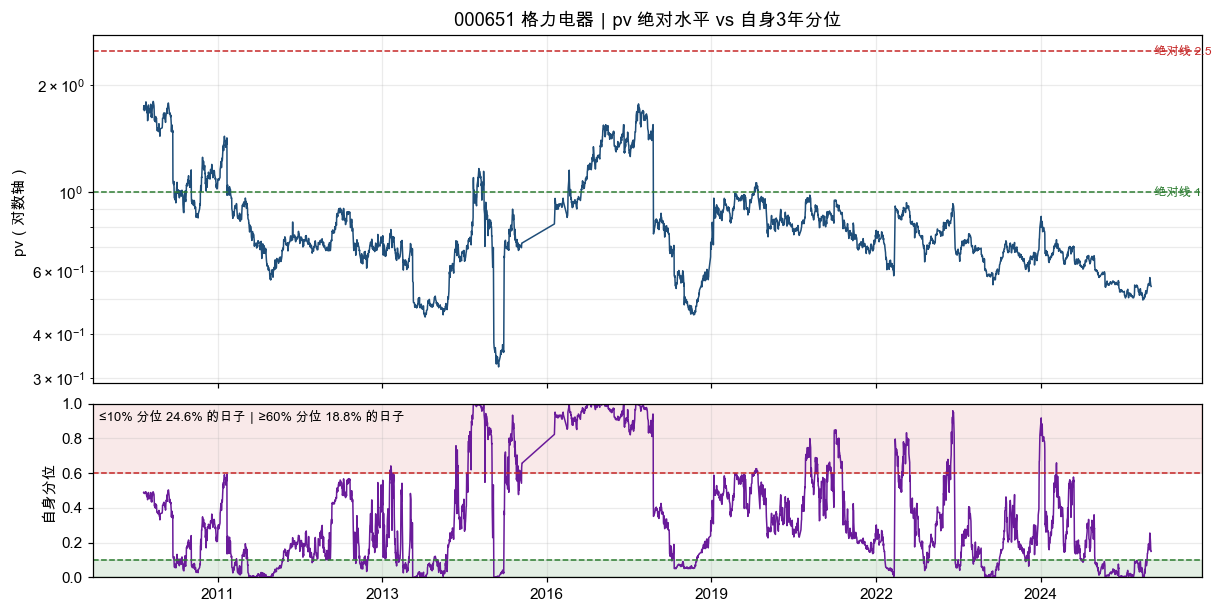

公司             天数     绝对P/V≤1     自身≤10%     自身≥60%
格力电器         3906      83.9%      24.6%      18.8%


海螺水泥         4062      87.2%      17.6%      16.5%


陕西煤业         2738      74.3%      16.1%      49.9%


迈瑞医疗         1520       0.0%      50.2%      18.1%


药明康德         1680       5.7%      27.0%      31.8%


中际旭创         2835       7.1%      14.9%      54.4%


宁德时代         1678      10.2%      18.7%      55.3%


贵州茅台         4068      16.7%      26.1%      41.1%


In [12]:
# ---------------------- 自身分位：配置 ----------------------
METRIC       = "pv"       # pv / pb / pe / pbroe
PCT_WINDOW   = 750        # 回看交易日；750≈3年、1250≈5年、0=自上市以来全历史
PCT_MIN_OBS  = 250        # 观测不足这么多就判不了分位（与回测 --quantile-min-obs 同义）
PCT_BUY      = 0.10       # 买入闸（与回测 --buy-pct 同义）
PCT_SELL     = 0.60       # 卖出闸（与回测 --sell-pct 同义）
# -----------------------------------------------------------

METRIC_FILES = {"pv": DAILY,
                "pb":    ROOT / "data/processed/metric_states/pb.csv",
                "pe":    ROOT / "data/processed/metric_states/pe.csv",
                "pbroe": ROOT / "data/processed/metric_states/pbroe.csv"}
_METRIC_CACHE = {}


def load_metric(code, metric="pv"):
    """{日期: 指标值}。`pv` 直接用逐日状态；其余三个指标文件由
    `scripts/experimental/build_metric_states.py` 生成（92MB 级，在 .gitignore 内）。"""
    key = (code, metric)
    if key in _METRIC_CACHE:
        return _METRIC_CACHE[key]
    path = METRIC_FILES[metric]
    if not path.exists():
        raise FileNotFoundError(
            f"缺 {path.relative_to(ROOT)}。重建：\n"
            f"  python3 scripts/experimental/build_metric_states.py --metric {metric} "
            f"--bands <采用口径重建的带.csv> --out {path.relative_to(ROOT)}")
    out, prefix = {}, code + ","
    with open(path, encoding="utf-8") as fh:
        head = next(fh).rstrip("\n").split(",")
        i_d, i_r = head.index("date"), head.index("valuation_ratio")
        for line in fh:
            if not line.startswith(prefix):
                continue
            f = line.rstrip("\n").split(",")
            try:
                out[f[i_d]] = float(f[i_r])
            except (ValueError, IndexError):
                pass
    _METRIC_CACHE[key] = out
    return out


def self_pct(days, values, window=PCT_WINDOW, min_obs=PCT_MIN_OBS):
    """逐日自身分位，**与回测 `--gate self-pct` 逐位同算**：
    第 t 日的分位 = t **之前** 窗口内小于当日值的观测占比；不足 `min_obs` 返回 None。
    当日这一条不参与自己的分位，故严格无前视。"""
    from collections import deque
    order, arr, out = deque(), [], []
    for v in values:
        out.append(bisect.bisect_left(arr, v) / len(arr) if len(arr) >= min_obs else None)
        order.append(v)
        bisect.insort(arr, v)
        if window and len(order) > window:
            old = order.popleft()
            del arr[bisect.bisect_left(arr, old)]
    return out


def plot_pct(code, metric=METRIC, since=SINCE, until=UNTIL):
    m = load_metric(code, metric)
    days = sorted(m)
    vals = [m[d] for d in days]
    pcts = self_pct(days, vals)
    sel = [i for i, d in enumerate(days) if (not since or d >= since) and (not until or d <= until)]
    if not sel:
        print(f"{code} 在该区间无数据"); return
    xs = [D(days[i]) for i in sel]

    fig, ax = plt.subplots(2, 1, figsize=(13, 6.4), sharex=True,
                           gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08})
    ax[0].semilogy(xs, [vals[i] for i in sel], lw=1.0, color="#1f4e79")
    if metric == "pv":
        for y, c in ((BUY_LINE, "#2e7d32"), (SELL_LINE, "#c62828")):
            ax[0].axhline(y, color=c, ls="--", lw=1.0)
            ax[0].text(xs[-1], y, f" 绝对线 {y:g}", color=c, va="center", fontsize=8)
    ax[0].set_ylabel(f"{metric}（对数轴）")
    ax[0].set_title(f"{code} {NAMES.get(code,'')}｜{metric} 绝对水平 vs 自身"
                    f"{'全历史' if not PCT_WINDOW else f'{PCT_WINDOW/244:.0f}年'}分位")
    ax[0].grid(alpha=.25, which="both")

    ok = [i for i in sel if pcts[i] is not None]
    ax[1].plot([D(days[i]) for i in ok], [pcts[i] for i in ok], lw=1.0, color="#6a1b9a")
    ax[1].axhspan(0, PCT_BUY, color="#2e7d32", alpha=.13)
    ax[1].axhspan(PCT_SELL, 1, color="#c62828", alpha=.10)
    ax[1].axhline(PCT_BUY, color="#2e7d32", ls="--", lw=1.0)
    ax[1].axhline(PCT_SELL, color="#c62828", ls="--", lw=1.0)
    ax[1].set_ylim(0, 1); ax[1].set_ylabel("自身分位")
    ax[1].grid(alpha=.25)
    ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    n = len(ok)
    if n:
        buyable = sum(1 for i in ok if pcts[i] <= PCT_BUY) / n
        rich = sum(1 for i in ok if pcts[i] >= PCT_SELL) / n
        ax[1].text(0.005, 0.90, f"≤{PCT_BUY:.0%} 分位 {buyable:.1%} 的日子｜"
                                f"≥{PCT_SELL:.0%} 分位 {rich:.1%} 的日子",
                   transform=ax[1].transAxes, fontsize=8.5)
    plt.show()


def pct_vs_abs(codes, metric=METRIC, since=SINCE):
    """两把尺各自放行多少天。**这张表是整个重构的取舍所在**。"""
    print(f"{'公司':<10}{'天数':>7}{'绝对P/V≤'+format(BUY_LINE,'g'):>12}"
          f"{'自身≤'+format(PCT_BUY,'.0%'):>11}{'自身≥'+format(PCT_SELL,'.0%'):>11}")
    for c in codes:
        m, pv = load_metric(c, metric), load_states(c)
        days = sorted(m)
        p = self_pct(days, [m[d] for d in days])
        ok = [i for i, d in enumerate(days) if d >= since and p[i] is not None]
        if not ok:
            print(f"{NAMES.get(c,c):<10}{'（历史不足）':>7}"); continue
        absok = [d for i, d in enumerate(days) if d >= since and d in pv and pv[d][1] <= BUY_LINE]
        nd = sum(1 for d in days if d >= since)
        print(f"{NAMES.get(c,c):<10}{len(ok):>7}{len(absok)/nd:>11.1%}"
              f"{sum(1 for i in ok if p[i] <= PCT_BUY)/len(ok):>11.1%}"
              f"{sum(1 for i in ok if p[i] >= PCT_SELL)/len(ok):>11.1%}")


plot_pct(CODE)
pct_vs_abs(["000651", "600585", "601225", "300760", "603259", "300308", "300750", "600519"])